In [56]:
def set_size(width_pt, fraction=1, subplots=(1, 1)):
    """Set figure dimensions to sit nicely in our document.

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

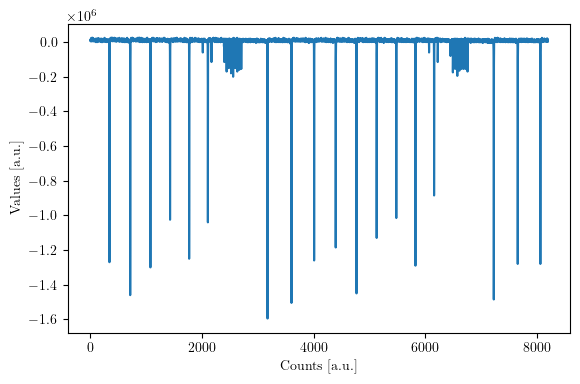

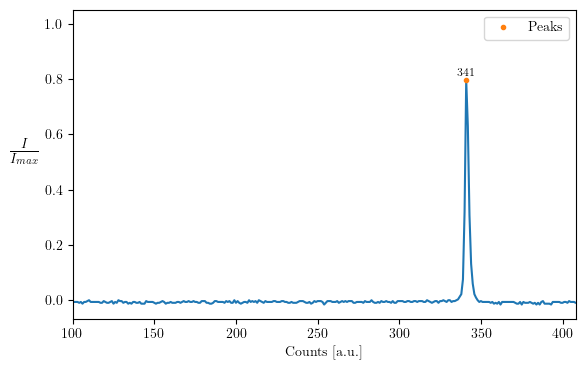

Average distance between peaks: 197.94871794871796
GHz per index: 0.002525906735751295


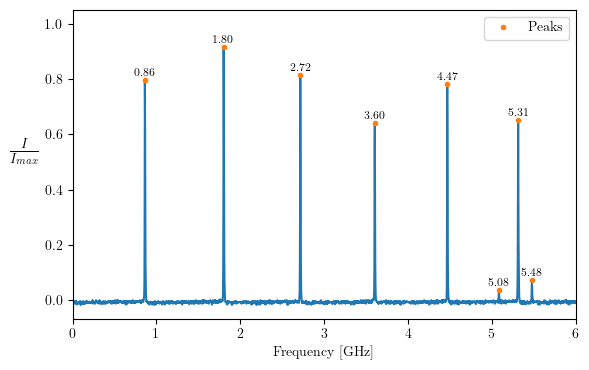

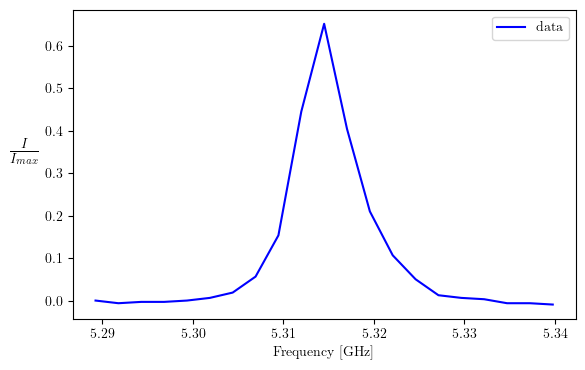

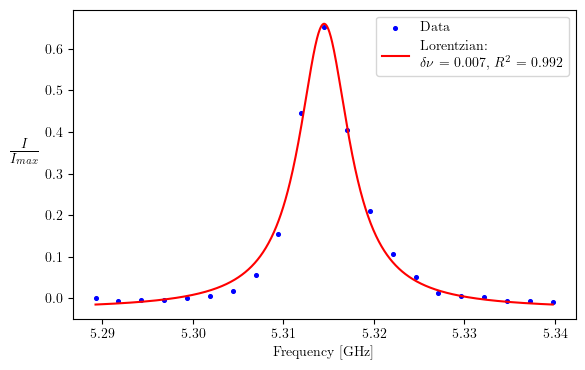

R^2= 0.9920240205981493
dv 0.006762726539043444
Finesse 147.86935331876444


In [57]:
# plot csv file
#import matplotlib as mpl
# Use the pgf backend (must be set before pyplot imported)
#mpl.use('pgf')
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

plt.rcParams.update({
    "font.family": "serif",  # use serif/main font for text elements
    "text.usetex": True,     # use inline math for ticks
    "pgf.rcfonts": False     # don't setup fonts from rc parameters
    })
plt.rcParams['font.size'] = 10


# Load the CSV file
data = pd.read_csv(r'102 mA 20,1 deg 1ms resolution with unblock.csv')

# Clean the column names by removing commas
data.columns = [col.replace(',', '') for col in data.columns]

# Convert the data to numeric values (removing commas in data)
data = data.replace({',': ''}, regex=True).apply(pd.to_numeric)

# Select the series with column name '20000'

series_data = data.iloc[:, 1]
limit = 600


# Plot the original series
plt.figure(figsize=set_size(469))
plt.plot(series_data)
plt.xlabel('Counts [a.u.]')
plt.ylabel('Values [a.u.]')
#plt.savefig(r'Latex\Figures\1\FPI_Data.pgf', format='pgf')
plt.show()

# Flip the data about the x-axis
flipped_series_data = -series_data

# Normalize the flipped data
normalized_flipped_series_data = (flipped_series_data) / (flipped_series_data.max())

# Find peaks in the flipped normalized series
peaks, _ = find_peaks(normalized_flipped_series_data, height = 0.03)

# Calculate distances between consecutive peaks
peak_distances = np.diff(peaks)

# Plot the flipped normalized series with peaks highlighted
fig, ax = plt.subplots(figsize=set_size(469))
ax.plot(normalized_flipped_series_data)
ax.plot(peaks, normalized_flipped_series_data[peaks], '.', label='Peaks')
ax.set_xlabel('Counts [a.u.]')
ax.set_ylabel(r'$\frac{I}{I_{max}}$', rotation='horizontal', labelpad=15, fontsize=14)


# Annotate the peaks
for peak in peaks:
    ax.annotate(peak, (peak, normalized_flipped_series_data[peak]), textcoords="offset points", xytext=(0,3), ha='center', fontsize=8, rotation=0)

ax.legend()
ax.set_xlim(100, 408)
#plt.savefig(r'Latex\Figures\1\FPI_Peaks.pgf', format='pgf')
plt.show()

# Compute the average distance between peaks in the filtered array
average_peak_distance = np.mean(peak_distances)
GHz_per_index = 0.5/ average_peak_distance
print(f'Average distance between peaks: {average_peak_distance}')
print(f'GHz per index: {GHz_per_index}')

# Compute the x-values in GHz
x_values_GHz = np.arange(len(normalized_flipped_series_data)) * GHz_per_index

# Plot the flipped normalized series with peaks highlighted
fig, ax = plt.subplots(figsize=set_size(469))
ax.plot(x_values_GHz, normalized_flipped_series_data)
ax.plot(peaks * GHz_per_index, normalized_flipped_series_data[peaks], '.', label='Peaks')
ax.set_xlabel('Frequency [GHz]')
ax.set_ylabel(r'$\frac{I}{I_{max}}$', rotation='horizontal', labelpad=15, fontsize=14)


# Annotate the peaks
for peak in peaks:
    ax.annotate(f'{peak * GHz_per_index:.2f}', (peak * GHz_per_index, normalized_flipped_series_data[peak]), textcoords="offset points", xytext=(0,3), ha='center', fontsize=8, rotation=0)

ax.legend()
ax.set_xlim(0, 6)
#ax.set_xlim(100 * GHz_per_index, 400 * GHz_per_index)
#plt.savefig(r'Latex\Figures\1\FPI_Peaks_GHz.pgf', format='pgf')
plt.show()


# Define the Lorentzian function with an amplitude parameter
def lorentzian(x, x0, dv, C, y0):
    return  y0 + (2*C/np.pi)*(dv / (4*(x - x0)**2 + (dv)**2))

peak_index = peaks[6]
window_size = 10 # Adjust as needed
window_indices = range(max(0, peak_index - window_size), min(len(normalized_flipped_series_data), peak_index + window_size + 1))
window_x = x_values_GHz[window_indices]
window_y = normalized_flipped_series_data[window_indices]

# Initial parameter estimates
x0_initial = x_values_GHz[peak_index]  # center frequency of the peak
gamma_initial = 0.1  # width of the peak
C_initial = max(window_y)  # height of the peak
y0_initial = normalized_flipped_series_data.min()  # offset

# Now you can use A_initial in your initial parameter estimates
p0 = [x0_initial, gamma_initial, C_initial, y0_initial]

fit_options = {'maxfev': 10000}

# Fit the Lorentzian function to the data in the window
popt, _ = curve_fit(lorentzian, window_x, window_y, p0=p0)

# Calculate the R^2 score for the original fit
predicted_y = lorentzian(window_x, *popt)
r2 = r2_score(window_y, predicted_y)


# Plot the original data and the fitted function for the window only
fig, ax = plt.subplots(figsize=set_size(469))
ax.plot(window_x, window_y, 'b-', label='data')
#ax.plot(window_x, predicted_y, 'r-', label=r'fit: $\delta \nu$=%5.6f, $R^2$=%5.3f' % (popt[1], r2))
ax.set_xlabel('Frequency [GHz]')
ax.set_ylabel(r'$\frac{I}{I_{max}}$', rotation='horizontal', labelpad=15, fontsize=14)
ax.legend()
plt.show()

# Generate high-resolution x-values
high_res_x = np.linspace(window_x.min(), window_x.max(), 1000)

# Calculate the corresponding y-values using the fitted parameters
high_res_y = lorentzian(high_res_x, *popt)

# Plot the original data and the high-resolution fitted function
fig, ax = plt.subplots(figsize=set_size(469))
ax.scatter(window_x, window_y, c='b', label='Data', s=7)
ax.plot(high_res_x, high_res_y, 'r-', label=r'Lorentzian:' + '\n' + r'$\delta \nu$' + f' = {popt[1]:.3f}, ' + r'$R^2$' + f' = {r2:.3f}')
ax.set_xlabel('Frequency [GHz]')
ax.set_ylabel(r'$\frac{I}{I_{max}}$', rotation='horizontal', labelpad=15, fontsize=14)

# Get handles and labels for legend
handles, labels = ax.get_legend_handles_labels()

# Create the legend
legend = ax.legend(handles, labels, loc='best', fancybox=True)

#plt.savefig(r'Latex\Figures\1\FPI_Fit.pgf', format='pgf')
plt.show()

print('R^2=', r2)
print('dv', popt[1])
print('Finesse', 1/popt[1])

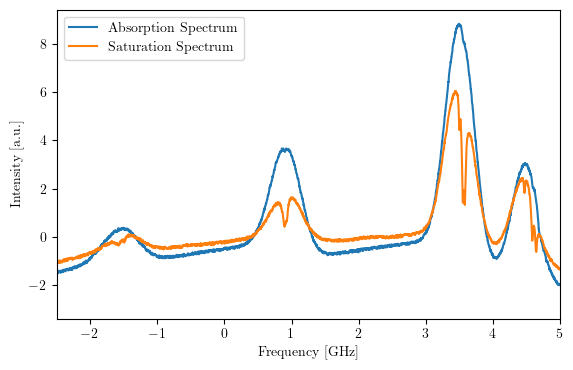

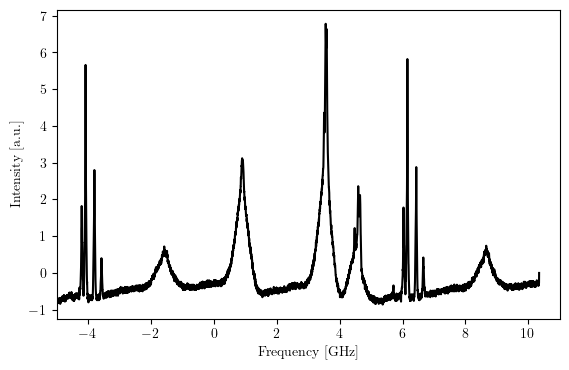

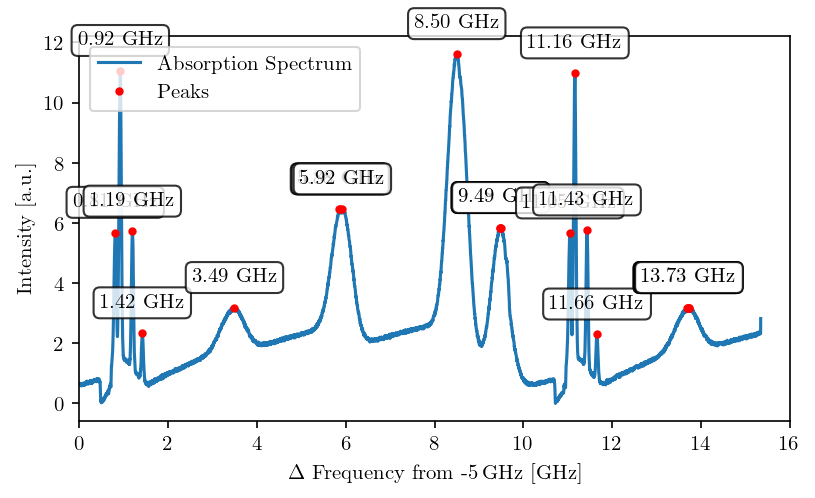

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
from matplotlib.patches import FancyArrowPatch

# Make sure GHz_per_index is defined (e.g., from your previous cell)
# GHz_per_index = 1 / average_peak_distance

plt.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False
})

def find_closest_column(df, target_value):
    best_col, best_diff = None, float("inf")
    for col in df.columns:
        col_clean = str(col).replace(",", "").strip()
        try:
            val = float(col_clean)
            diff = abs(val - target_value)
            if diff < best_diff:
                best_diff, best_col = diff, col
        except ValueError:
            continue
    if best_col is None:
        raise KeyError(f"No numeric column found near {target_value}")
    return best_col

# --- Load & clean ---
data1 = pd.read_csv(r'102 mA 20,1 deg 1ms resolution with unblock.csv')
data2 = pd.read_csv(r'102 mA 20,1 deg 1ms resolution.csv')
data1 = data1.replace({',': ''}, regex=True).apply(pd.to_numeric, errors='ignore')
data2 = data2.replace({',': ''}, regex=True).apply(pd.to_numeric, errors='ignore')

# --- Pick the right columns dynamically ---
col1 = find_closest_column(data1, -50000)
col2 = find_closest_column(data2, -84000)
s1 = data1[col1].values
s2 = data2[col2].values

# --- Build a zero-centered frequency axis ---
n = len(s2)
zero_idx = n // 2
freq_axis = (np.arange(n) - zero_idx) * GHz_per_index

# --- Turn into pandas Series ---
series1 = pd.Series(s1 / 1e5, index=freq_axis)
series2 = pd.Series(s2 / 1e5, index=freq_axis)

# --- Plot absorption vs. saturation (–5 to +11 GHz) ---
plt.figure(figsize=set_size(469))
plt.plot(series2, label='Absorption Spectrum')
plt.plot(series1, label='Saturation Spectrum')
plt.xlim(-2.5, 5)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Intensity [a.u.]')
plt.legend()
plt.show()

# --- Plot their difference (–5 to +11 GHz) ---
plt.figure(figsize=set_size(469))
plt.plot(series2 - series1, color='black')
plt.xlim(-5, 11)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Intensity [a.u.]')
plt.show()

# --- Peak‐finding on the full absorption spectrum ---
whole = series2 - series2.min()
peaks, _ = find_peaks(whole, distance=2, prominence=1)


# --- Plot all peaks with shifted axis so –5→0 (0 to 16 GHz), high-DPI and boxed labels ---
shift = 5.0
new_x = whole.index + shift  # now ranges from –5→0 up to 11→16

fig, ax = plt.subplots(figsize=set_size(400), dpi=150)      # higher DPI
ax.plot(new_x, whole, label='Absorption Spectrum')
ax.plot(new_x[peaks], whole.iloc[peaks], 'r.', label='Peaks')
ax.set_xlim(0, 16)

# Annotate only peaks that were originally between –5 and +11 GHz
for pk in peaks:
    old_freq = whole.index[pk]
    if -5 <= old_freq <= 11:
        x_shifted = old_freq + shift
        ax.annotate(
            f'{x_shifted:.2f} GHz',
            (x_shifted, whole.iloc[pk]),
            xytext=(0, 12),                      # raise text further
            textcoords="offset points",
            ha='center',
            fontsize=10,                         # slightly larger
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
        )

ax.set_xlabel(r'$\Delta$ Frequency from -5\,GHz [GHz]')
ax.set_ylabel('Intensity [a.u.]')
ax.legend()
plt.tight_layout()
plt.show()

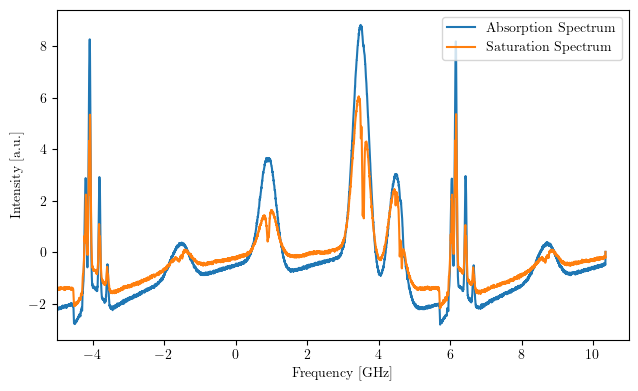

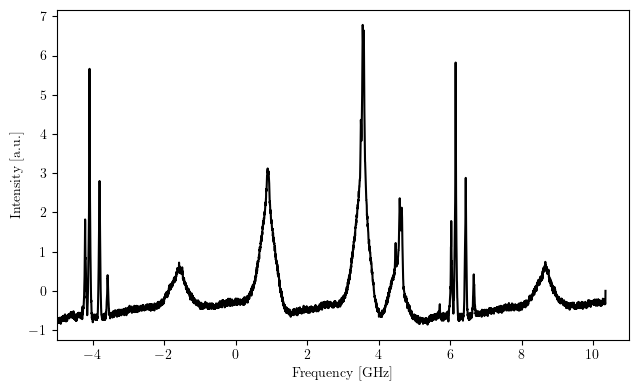

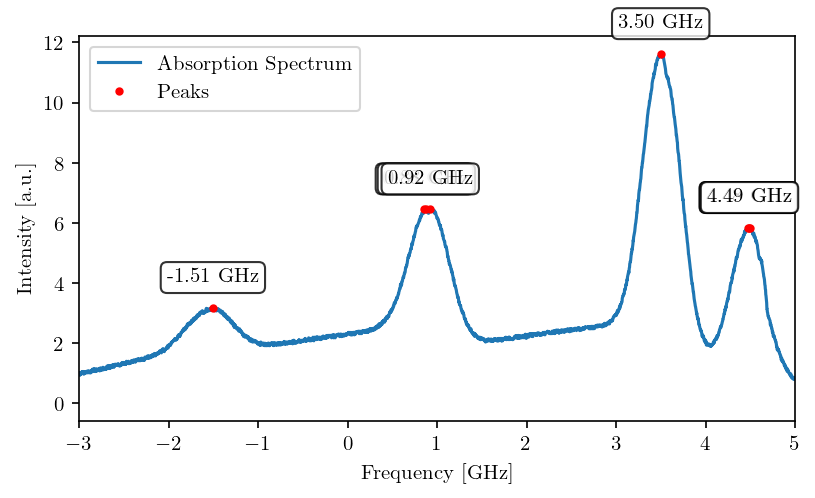

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
from matplotlib.patches import FancyArrowPatch

# Make sure GHz_per_index is defined (e.g., from your previous cell)
# GHz_per_index = 1 / average_peak_distance

plt.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False
})

def find_closest_column(df, target_value):
    best_col, best_diff = None, float("inf")
    for col in df.columns:
        col_clean = str(col).replace(",", "").strip()
        try:
            val = float(col_clean)
            diff = abs(val - target_value)
            if diff < best_diff:
                best_diff, best_col = diff, col
        except ValueError:
            continue
    if best_col is None:
        raise KeyError(f"No numeric column found near {target_value}")
    return best_col

# --- Load & clean ---
data1 = pd.read_csv(r'102 mA 20,1 deg 1ms resolution with unblock.csv')
data2 = pd.read_csv(r'102 mA 20,1 deg 1ms resolution.csv')
data1 = data1.replace({',': ''}, regex=True).apply(pd.to_numeric, errors='ignore')
data2 = data2.replace({',': ''}, regex=True).apply(pd.to_numeric, errors='ignore')

# --- Pick the right columns dynamically ---
col1 = find_closest_column(data1, -50000)
col2 = find_closest_column(data2, -84000)
s1 = data1[col1].values
s2 = data2[col2].values

# --- Build a zero-centered frequency axis ---
n = len(s2)
zero_idx = n // 2
freq_axis = (np.arange(n) - zero_idx) * GHz_per_index

# --- Turn into pandas Series ---
series1 = pd.Series(s1 / 1e5, index=freq_axis)
series2 = pd.Series(s2 / 1e5, index=freq_axis)

# --- Plot absorption vs. saturation (–5 to +11 GHz) ---
plt.figure(figsize=set_size(469))
plt.plot(series2, label='Absorption Spectrum')
plt.plot(series1, label='Saturation Spectrum')
plt.xlim(-5, 11)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Intensity [a.u.]')
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot their difference (–5 to +11 GHz) ---
plt.figure(figsize=set_size(469))
plt.plot(series2 - series1, color='black')
plt.xlim(-5, 11)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Intensity [a.u.]')
plt.tight_layout()
plt.show()

# --- Peak‐finding on the full absorption spectrum ---
whole = series2 - series2.min()
peaks, _ = find_peaks(whole, distance=2, prominence=1)

# --- Plot all peaks on the original axis (–5 to +11 GHz) ---
fig, ax = plt.subplots(figsize=set_size(400), dpi=150)
ax.plot(whole.index, whole, label='Absorption Spectrum')
ax.plot(whole.index[peaks], whole.iloc[peaks], 'r.', label='Peaks')
ax.set_xlim(-3, 5)

# Annotate only peaks between –5 and +11 GHz
for pk in peaks:
    freq = whole.index[pk]
    if -5 <= freq <= 11:
        ax.annotate(
            f'{freq:.2f} GHz',
            (freq, whole.iloc[pk]),
            xytext=(0, 12),            # raise text above the point
            textcoords='offset points',
            ha='center',
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
        )

ax.set_xlabel('Frequency [GHz]')
ax.set_ylabel('Intensity [a.u.]')
ax.legend()
plt.tight_layout()
plt.show()


In [37]:
diff_series = series2 - series1


-3.02 GHz peak fit:
  A     = 0.6629 ± 0.0219
  f₀    = -1.58710 ± 0.00146 GHz
  σ     = 0.1253 ± 0.0101 GHz
  γ     = 0.1591 ± 0.0142 GHz
  C     = -0.4510 ± 0.0073
Voigt FWHM = 0.5003 GHz


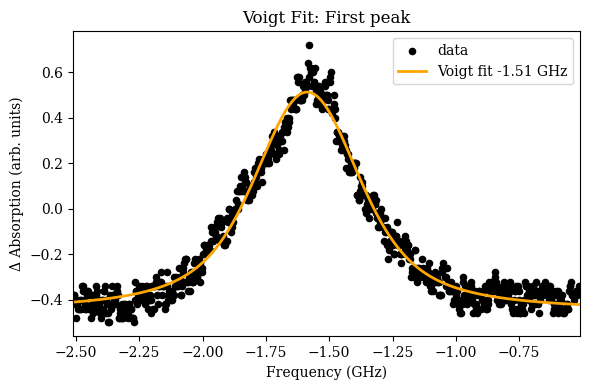

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

plt.rcParams['text.usetex'] = False

x = diff_series.index.values
y = diff_series.values

def voigt_plus_offset(f, A, f0, sigma, gamma, C):
    return A * voigt_profile(f - f0, sigma, gamma) + C

# Select the window around the 13.98 GHz peak
center = -1.51
window = 1
mask = (x >= center - window) & (x <= center + window)
xw, yw = x[mask], y[mask]

# Initial guesses and bounds
p0 = [yw.max() - yw.min(), center, 0.05, 0.05, yw.min()]
lower = [0, center - 0.2,  0.001, 0.001, -np.inf]
upper = [np.inf, center + 0.2, 1.0,   1.0,   np.inf]

# Perform the fit
popt, pcov = curve_fit(voigt_plus_offset, xw, yw, p0=p0, bounds=(lower, upper))
perr = np.sqrt(np.diag(pcov))
A_fit, f0_fit, s_fit, g_fit, C_fit = popt
errA, errf0, errs, errg, errC = perr

print("-3.02 GHz peak fit:")
print(f"  A     = {A_fit:.4f} ± {errA:.4f}")
print(f"  f₀    = {f0_fit:.5f} ± {errf0:.5f} GHz")
print(f"  σ     = {s_fit:.4f} ± {errs:.4f} GHz")
print(f"  γ     = {g_fit:.4f} ± {errg:.4f} GHz")
print(f"  C     = {C_fit:.4f} ± {errC:.4f}")

# --- Compute Voigt FWHM via Olivero–Longbothum ---
# 2*gamma is the Lorentzian FWHM, and 2*sqrt(2 ln2)*sigma is the Gaussian FWHM
lorentz_fwhm = 2 * g_fit
gauss_fwhm    = 2 * np.sqrt(2 * np.log(2)) * s_fit

fwhm_voigt = (
    0.5346 * lorentz_fwhm
    + np.sqrt(0.2166 * lorentz_fwhm**2 + gauss_fwhm**2)
)

print(f"Voigt FWHM = {fwhm_voigt:.4f} GHz")

# Plotting
fine_x = np.linspace(center - window, center + window, 500)
plt.figure(figsize=(6,4))
plt.scatter(xw, yw, s=20, color='black', label='data')
plt.plot(fine_x, voigt_plus_offset(fine_x, *popt),
         lw=2, color='orange', label='Voigt fit -1.51 GHz')
plt.xlim(center - window, center + window)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Δ Absorption (arb. units)')
plt.title('Voigt Fit: First peak')
plt.legend()
plt.tight_layout()
plt.show()


1.84 GHz peak fit:
  A     = 1.4585 ± 0.0199
  f₀    = 0.88856 ± 0.00105 GHz
  σ     = 0.1511 ± 0.0039 GHz
  γ     = 0.0548 ± 0.0063 GHz
  C     = -0.4095 ± 0.0054
Voigt FWHM = 0.4182 GHz


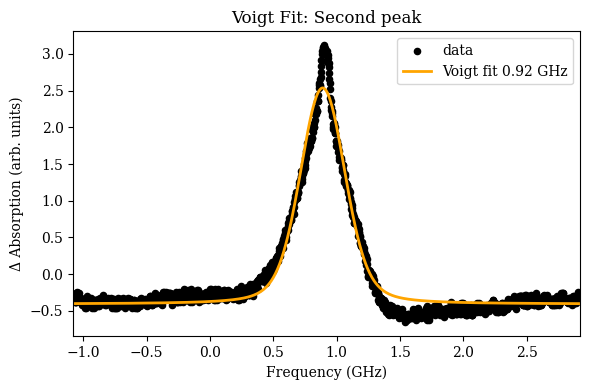

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

plt.rcParams['text.usetex'] = False

x = diff_series.index.values
y = diff_series.values

def voigt_plus_offset(f, A, f0, sigma, gamma, C):
    return A * voigt_profile(f - f0, sigma, gamma) + C

# Select the window around the 13.98 GHz peak
center = 0.92
window = 2.0
mask = (x >= center - window) & (x <= center + window)
xw, yw = x[mask], y[mask]

# Initial guesses and bounds
p0 = [yw.max() - yw.min(), center, 0.05, 0.05, yw.min()]
lower = [0, center - 0.2,  0.001, 0.001, -np.inf]
upper = [np.inf, center + 0.2, 1.0,   1.0,   np.inf]

# Perform the fit
popt, pcov = curve_fit(voigt_plus_offset, xw, yw, p0=p0, bounds=(lower, upper))
perr = np.sqrt(np.diag(pcov))
A_fit, f0_fit, s_fit, g_fit, C_fit = popt
errA, errf0, errs, errg, errC = perr

print("1.84 GHz peak fit:")
print(f"  A     = {A_fit:.4f} ± {errA:.4f}")
print(f"  f₀    = {f0_fit:.5f} ± {errf0:.5f} GHz")
print(f"  σ     = {s_fit:.4f} ± {errs:.4f} GHz")
print(f"  γ     = {g_fit:.4f} ± {errg:.4f} GHz")
print(f"  C     = {C_fit:.4f} ± {errC:.4f}")

# --- Compute Voigt FWHM via Olivero–Longbothum ---
# 2*gamma is the Lorentzian FWHM, and 2*sqrt(2 ln2)*sigma is the Gaussian FWHM
lorentz_fwhm = 2 * g_fit
gauss_fwhm    = 2 * np.sqrt(2 * np.log(2)) * s_fit

fwhm_voigt = (
    0.5346 * lorentz_fwhm
    + np.sqrt(0.2166 * lorentz_fwhm**2 + gauss_fwhm**2)
)

print(f"Voigt FWHM = {fwhm_voigt:.4f} GHz")

# Plotting
fine_x = np.linspace(center - window, center + window, 500)
plt.figure(figsize=(6,4))
# Plot data as black points
plt.scatter(xw, yw, s=20, color='black', label='data')
# Plot Voigt fit as an orange line
plt.plot(fine_x, voigt_plus_offset(fine_x, *popt),
         lw=2, color='orange', label='Voigt fit 0.92 GHz')
plt.xlim(center - window, center + window)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Δ Absorption (arb. units)')
plt.title('Voigt Fit: Second peak')
plt.legend()
plt.tight_layout()
plt.show()


7.00 GHz peak fit:
  A     = 1.7827 ± 0.0819
  f₀    = 3.55636 ± 0.00133 GHz
  σ     = 0.0010 ± 0.2597 GHz
  γ     = 0.0950 ± 0.0079 GHz
  C     = -0.1696 ± 0.0608
Voigt FWHM = 0.1901 GHz


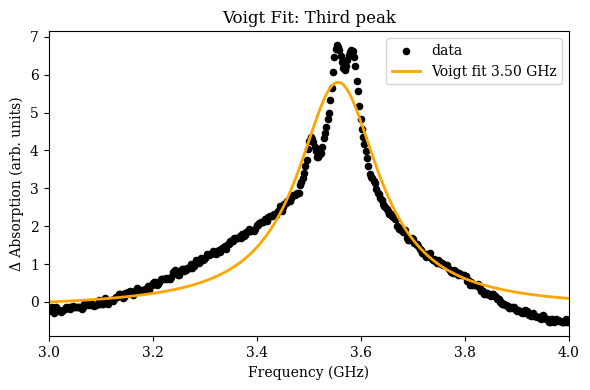

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

plt.rcParams['text.usetex'] = False

x = diff_series.index.values
y = diff_series.values

def voigt_plus_offset(f, A, f0, sigma, gamma, C):
    return A * voigt_profile(f - f0, sigma, gamma) + C

# Select the window around the 13.98 GHz peak
center = 3.50
window = 0.5
mask = (x >= center - window) & (x <= center + window)
xw, yw = x[mask], y[mask]

# Initial guesses and bounds
p0 = [yw.max() - yw.min(), center, 0.05, 0.05, yw.min()]
lower = [0, center - 0.2,  0.001, 0.001, -np.inf]
upper = [np.inf, center + 0.2, 1.0,   1.0,   np.inf]

# Perform the fit
popt, pcov = curve_fit(voigt_plus_offset, xw, yw, p0=p0, bounds=(lower, upper))
perr = np.sqrt(np.diag(pcov))
A_fit, f0_fit, s_fit, g_fit, C_fit = popt
errA, errf0, errs, errg, errC = perr

print("7.00 GHz peak fit:")
print(f"  A     = {A_fit:.4f} ± {errA:.4f}")
print(f"  f₀    = {f0_fit:.5f} ± {errf0:.5f} GHz")
print(f"  σ     = {s_fit:.4f} ± {errs:.4f} GHz")
print(f"  γ     = {g_fit:.4f} ± {errg:.4f} GHz")
print(f"  C     = {C_fit:.4f} ± {errC:.4f}")

# --- Compute Voigt FWHM via Olivero–Longbothum ---
# 2*gamma is the Lorentzian FWHM, and 2*sqrt(2 ln2)*sigma is the Gaussian FWHM
lorentz_fwhm = 2 * g_fit
gauss_fwhm    = 2 * np.sqrt(2 * np.log(2)) * s_fit

fwhm_voigt = (
    0.5346 * lorentz_fwhm
    + np.sqrt(0.2166 * lorentz_fwhm**2 + gauss_fwhm**2)
)

print(f"Voigt FWHM = {fwhm_voigt:.4f} GHz")

# Plotting
fine_x = np.linspace(center - window, center + window, 500)
plt.figure(figsize=(6,4))
# Plot data as black points
plt.scatter(xw, yw, s=20, color='black', label='data')
# Plot Voigt fit as an orange line
plt.plot(fine_x, voigt_plus_offset(fine_x, *popt),
         lw=2, color='orange', label='Voigt fit 3.50 GHz')
plt.xlim(center - window, center + window)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Δ Absorption (arb. units)')
plt.title('Voigt Fit: Third peak')
plt.legend()
plt.tight_layout()
plt.show()


8.98 GHz peak fit:
  A     = 0.5379 ± 0.0598
  f₀    = 4.57210 ± 0.00320 GHz
  σ     = 0.1097 ± 0.0142 GHz
  γ     = 0.0010 ± 0.0285 GHz
  C     = -0.4369 ± 0.0361
Voigt FWHM = 0.2594 GHz


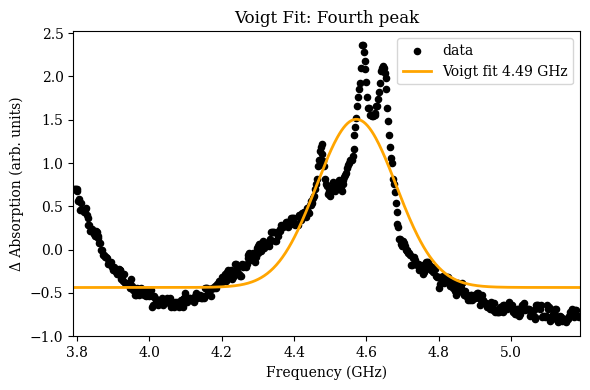

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

plt.rcParams['text.usetex'] = False

x = diff_series.index.values
y = diff_series.values

def voigt_plus_offset(f, A, f0, sigma, gamma, C):
    return A * voigt_profile(f - f0, sigma, gamma) + C

# Select the window around the 13.98 GHz peak
center = 4.49
window = 0.7
mask = (x >= center - window) & (x <= center + window)
xw, yw = x[mask], y[mask]

# Initial guesses and bounds
p0 = [yw.max() - yw.min(), center, 0.05, 0.05, yw.min()]
lower = [0, center - 0.2,  0.001, 0.001, -np.inf]
upper = [np.inf, center + 0.2, 1.0,   1.0,   np.inf]

# Perform the fit
popt, pcov = curve_fit(voigt_plus_offset, xw, yw, p0=p0, bounds=(lower, upper))
perr = np.sqrt(np.diag(pcov))
A_fit, f0_fit, s_fit, g_fit, C_fit = popt
errA, errf0, errs, errg, errC = perr

print("8.98 GHz peak fit:")
print(f"  A     = {A_fit:.4f} ± {errA:.4f}")
print(f"  f₀    = {f0_fit:.5f} ± {errf0:.5f} GHz")
print(f"  σ     = {s_fit:.4f} ± {errs:.4f} GHz")
print(f"  γ     = {g_fit:.4f} ± {errg:.4f} GHz")
print(f"  C     = {C_fit:.4f} ± {errC:.4f}")

# --- Compute Voigt FWHM via Olivero–Longbothum ---
# 2*gamma is the Lorentzian FWHM, and 2*sqrt(2 ln2)*sigma is the Gaussian FWHM
lorentz_fwhm = 2 * g_fit
gauss_fwhm    = 2 * np.sqrt(2 * np.log(2)) * s_fit

fwhm_voigt = (
    0.5346 * lorentz_fwhm
    + np.sqrt(0.2166 * lorentz_fwhm**2 + gauss_fwhm**2)
)

print(f"Voigt FWHM = {fwhm_voigt:.4f} GHz")

# Plotting
fine_x = np.linspace(center - window, center + window, 500)
plt.figure(figsize=(6,4))
# Plot data as black points
plt.scatter(xw, yw, s=20, color='black', label='data')
# Plot Voigt fit as an orange line
plt.plot(fine_x, voigt_plus_offset(fine_x, *popt),
         lw=2, color='orange', label='Voigt fit 4.49 GHz')
plt.xlim(center - window, center + window)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Δ Absorption (arb. units)')
plt.title('Voigt Fit: Fourth peak')
plt.legend()
plt.tight_layout()
plt.show()


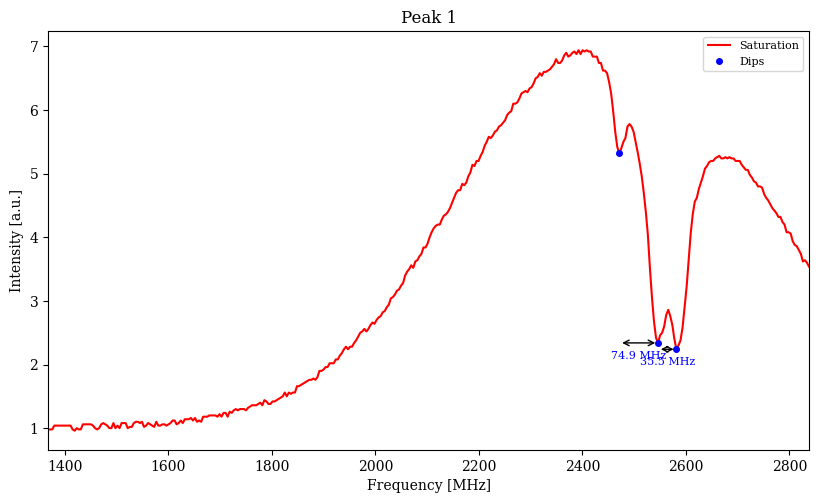

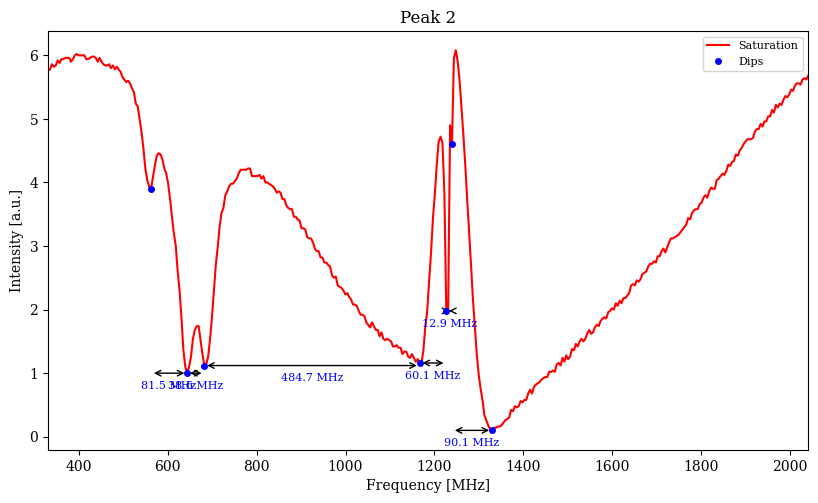

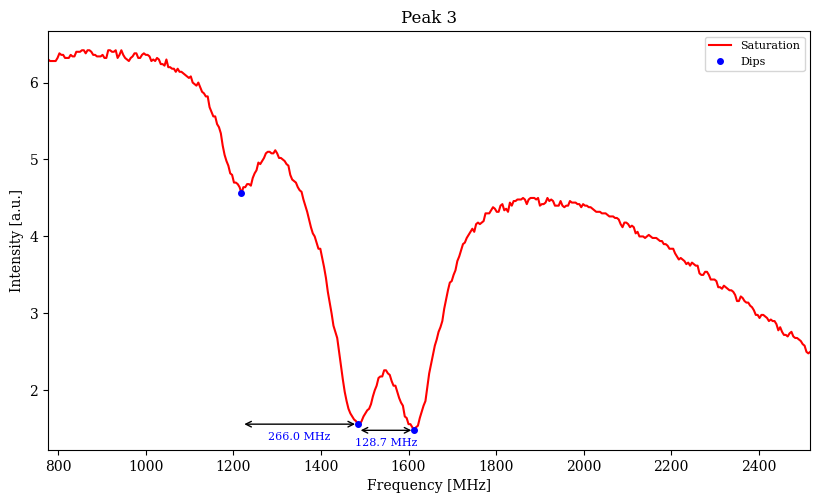

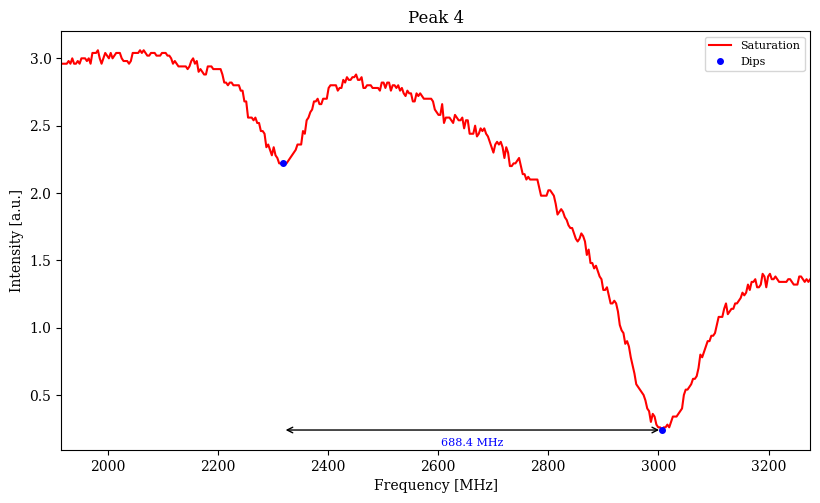

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from matplotlib.patches import FancyArrowPatch

# your per-peak window sizes (lower, upper) in sample-points
window_sizes = {
    1: (260, 114),
    2: (-15, 385),
    3: (-18, 389),
    4: (-20, 390),
}

# your per-peak calibration in GHz/index
GHz_per_index = [
    0.003941372090158887,
    0.004289679535705274,
    0.004289679535705274,
    0.0033255327010715606,
]

def set_size(width_pt, fraction=1):
    inches_per_pt = 1/72.27
    golden_ratio = (np.sqrt(5) - 1)/2
    w = width_pt * fraction * inches_per_pt
    return (w, w*golden_ratio)

for i in range(1,5):
    # 1) load & clean
    df = pd.read_csv(f'Peak {i}.csv')
    df.columns = [c.replace(',', '') for c in df.columns]
    df = df.replace({',':''}, regex=True).apply(pd.to_numeric)
    series = df.iloc[:,0] / 1e5
    series -= series.min()

    # 2) find all peaks, take the first one
    peaks, _ = find_peaks(series, prominence=0.5)
    if peaks.size == 0:
        print(f"no peaks found in file {i}")
        continue
    pk = peaks[0]

    # 3) build window
    lo, hi = window_sizes[i]
    start = max(pk - abs(lo), 0)
    end   = min(pk + abs(hi), len(series))
    if end <= start:
        print(f"invalid window for peak {i}")
        continue

    window_idx = np.arange(start, end)
    window_data = series.iloc[start:end].to_numpy()

    # 4) convert to MHz
    conv = GHz_per_index[i-1] * 1e3
    freqs_MHz = window_idx * conv

    # 5) find dips (inverted peaks) and maxima
    dips, _  = find_peaks(-window_data, prominence=0.11)
    pks, _   = find_peaks(window_data,  prominence=0.13)

    # 6) manual tweaks, if you still need them:
    #    (I recommend you inspect dips/pks arrays here)

    # 7) compute dip distances
    dip_freqs = freqs_MHz[dips]
    dip_distances = np.diff(dip_freqs)

    # 8) plot
    fig, ax = plt.subplots(figsize=set_size(600))
    ax.plot(freqs_MHz, window_data, 'r-', label='Saturation')
    ax.plot(dip_freqs, window_data[dips], 'bo', ms=4, label='Dips')

    # annotate every dip-distance with a double arrow
    for j in range(len(dip_distances)):
        x1, x2 = dip_freqs[j], dip_freqs[j+1]
        y0 = min(window_data[dips[j]], window_data[dips[j+1]])
        arrow = FancyArrowPatch((x1, y0), (x2, y0),
                                arrowstyle='<->', mutation_scale=10)
        ax.add_patch(arrow)
        ax.text((x1+x2)/2, y0 - 0.02*(window_data.max()-window_data.min()),
                f"{dip_distances[j]:.1f} MHz",
                ha='center', va='top', fontsize=8, color='blue')

    ax.set_xlim(freqs_MHz.min(), freqs_MHz.max())
    ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Intensity [a.u.]')
    ax.set_title(f"Peak {i}")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
